**Credit Risk Analytics & Default Prediction System**

**DATA LOADING**

In [84]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/Loan_Default.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [87]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [88]:
print("Target distribution:")
print(df['Status'].value_counts())
print()
print("Default rate:", round(df['Status'].mean() * 100, 2), "%")

Target distribution:
Status
0    112031
1     36639
Name: count, dtype: int64

Default rate: 24.64 %


**EDA**(It is performed on the **raw data** before any cleaning or transformation, so we see the true distribution of the original dataset.)

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
property_value               15098
LTV                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term                            41
dtype: int64


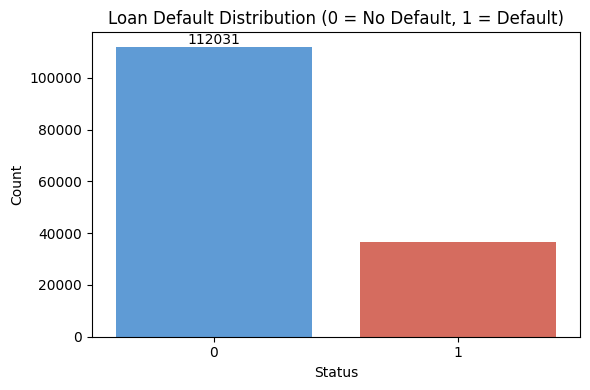

In [90]:
# Target distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Status', data=df, palette=['#4C9BE8', '#E85D4C'])
ax.bar_label(ax.containers[0])
plt.title("Loan Default Distribution (0 = No Default, 1 = Default)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The dataset is imbalanced — ~24% defaults vs 76% non-defaults. This requires using `class_weight='balanced'` in our models to avoid the classifier simply predicting 'no default' for everything.

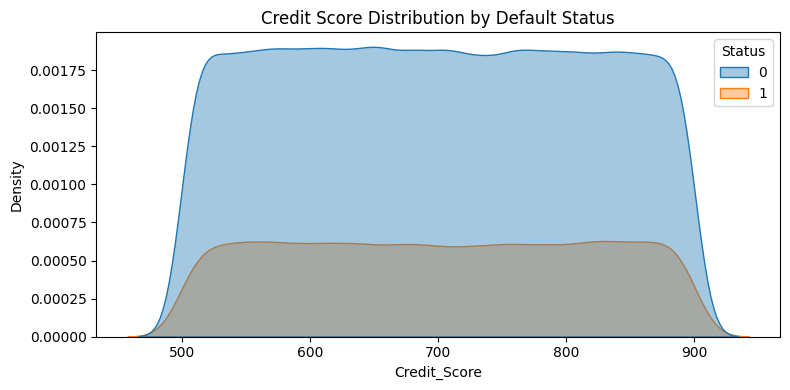

In [91]:
# Credit Score vs Default
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='Credit_Score', hue='Status', fill=True, alpha=0.4)
plt.title("Credit Score Distribution by Default Status")
plt.tight_layout()
plt.show()

Defaulters tend to have lower credit scores, but the distributions overlap significantly. This means credit score alone is insufficient — the model needs multiple features to separate risky borrowers effectively.

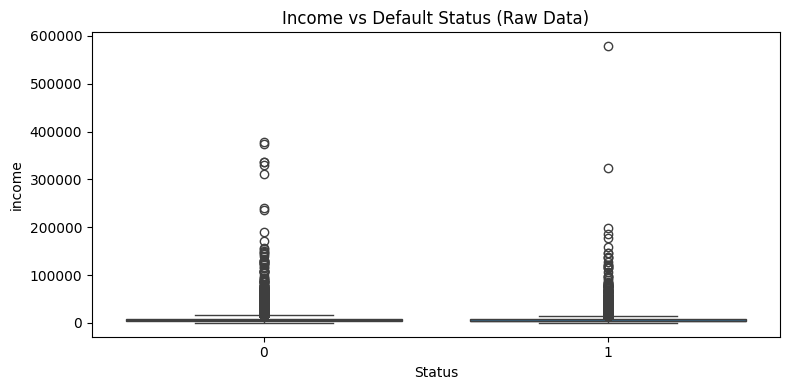

In [92]:
# Income vs Default (raw data before outlier removal)
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='income', data=df)
plt.title("Income vs Default Status (Raw Data)")
plt.tight_layout()
plt.show()

Lower-income borrowers are more likely to default. The wide spread of outliers in the raw data confirms why we need IQR-based outlier removal in cleaning — extreme incomes would distort the model.

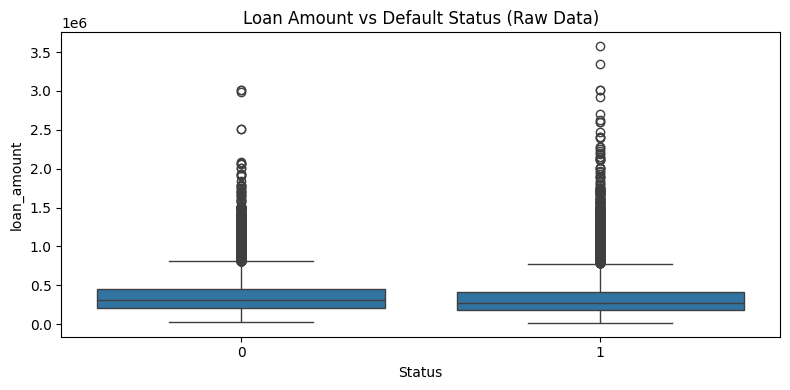

In [93]:
# Loan Amount vs Default
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='loan_amount', data=df)
plt.title("Loan Amount vs Default Status (Raw Data)")
plt.tight_layout()
plt.show()

Loan amount shows modest separation between default and non-default groups. Very large loans carry slightly higher default risk, suggesting the bank should apply stricter underwriting criteria for jumbo loans.

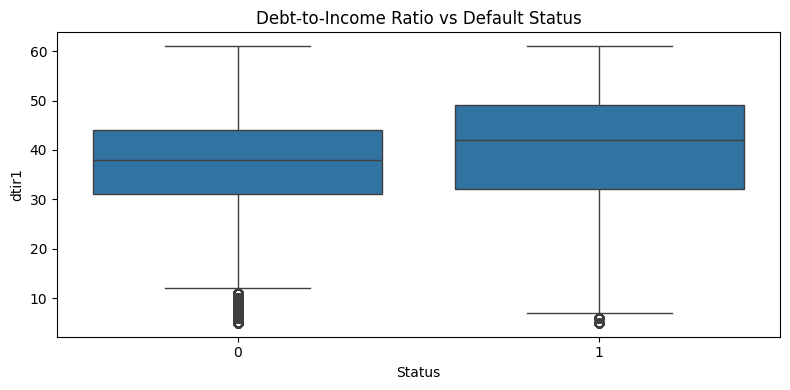

In [94]:
# DTI Ratio vs Default
plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='dtir1', data=df)
plt.title("Debt-to-Income Ratio vs Default Status")
plt.tight_layout()
plt.show()

Higher DTI ratios are a strong signal of default risk. Borrowers who default have a noticeably higher median DTI, confirming that debt burden relative to income is a key underwriting variable.

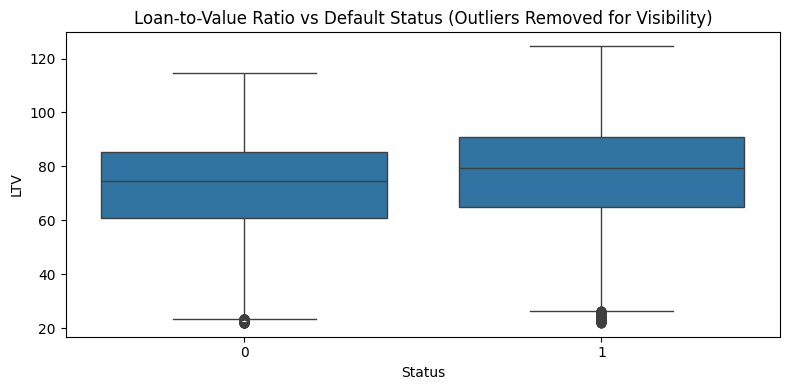

In [95]:
# LTV vs Default
Q1_ltv = df['LTV'].quantile(0.25)
Q3_ltv = df['LTV'].quantile(0.75)
IQR_ltv = Q3_ltv - Q1_ltv
df_ltv = df[(df['LTV'] >= Q1_ltv - 1.5*IQR_ltv) & (df['LTV'] <= Q3_ltv + 1.5*IQR_ltv)]

plt.figure(figsize=(8, 4))
sns.boxplot(x='Status', y='LTV', data=df_ltv)
plt.title("Loan-to-Value Ratio vs Default Status (Outliers Removed for Visibility)")
plt.tight_layout()
plt.show()

Borrowers with higher LTV ratios (i.e. smaller down payments relative to property value) show a higher tendency to default. This makes intuitive sense — less equity means less financial skin in the game.

In [96]:
# Categorical feature exploration
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print("------")

loan_limit:
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64
------
Gender:
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64
------
approv_in_adv:
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64
------
loan_type:
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64
------
loan_purpose:
loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64
------
Credit_Worthiness:
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64
------
open_credit:
open_credit
nopc    148114
opc        556
Name: count, dtype: int64
------
business_or_commercial:
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64
------
Neg_ammortization:
Neg_ammortization
not_neg    133420
neg_amm     15129
Name: count, dtype: int64
------
interest_only:
interest_only
not_int     141560
int_on

**DATA CLEANING**

In [97]:
# ── Save original loan_amount BEFORE any transformation ──
# This is used later for Expected Loss calculation in real dollar terms
df['loan_amount_original'] = df['loan_amount'].copy()

print("Original loan_amount sample:", df['loan_amount'].head(3).values)

Original loan_amount sample: [116500 206500 406500]


In [98]:
# ── Fill missing values ──
# Numeric: fill with median (robust to outliers)
# Categorical: fill with mode (most frequent value)

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after fill:", df.isnull().sum().sum())

Missing values after fill: 0


In [99]:
# ── Drop duplicates and ID column ──
df = df.drop_duplicates()
df = df.drop('ID', axis=1)
print(f"Shape after deduplication: {df.shape}")

Shape after deduplication: (148670, 34)


In [100]:
# ── IQR outlier removal for skewed numeric columns ──
for col in ['income', 'loan_amount', 'Credit_Score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    print(f"{col}: removed {before - len(df)} rows")

print(f"Final shape: {df.shape}")

income: removed 7636 rows
loan_amount: removed 1066 rows
Credit_Score: removed 0 rows
Final shape: (139968, 34)


In [101]:
# ── One-hot encoding for categorical columns ──
df = pd.get_dummies(df, drop_first=True)

# Convert booleans to int
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Ensure Status is int
df['Status'] = df['Status'].astype(int)

print(f"Shape after encoding: {df.shape}")
print(f"Default rate preserved: {df['Status'].mean():.3f}")

Shape after encoding: (139968, 51)
Default rate preserved: 0.246


**Feature Correlation Analysis**

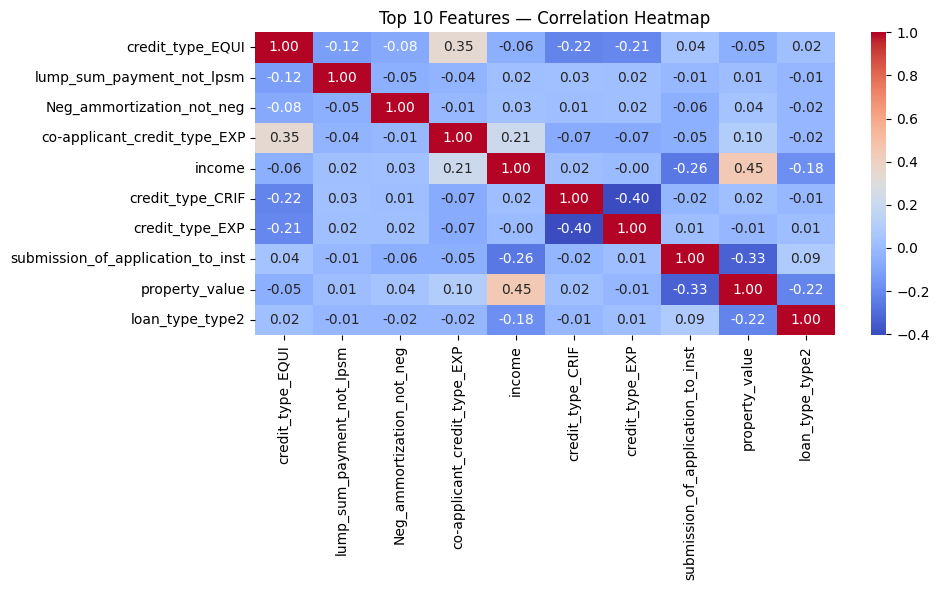


Top 10 features correlated with default:
credit_type_EQUI                     0.591292
lump_sum_payment_not_lpsm            0.187715
Neg_ammortization_not_neg            0.156442
co-applicant_credit_type_EXP         0.149206
income                               0.143006
credit_type_CRIF                     0.126464
credit_type_EXP                      0.125173
submission_of_application_to_inst    0.120708
property_value                       0.101863
loan_type_type2                      0.096308
Name: Status, dtype: float64


In [102]:
# Keep loan_amount_original out of correlation (it's for business use, not modelling)
corr_df = df.drop(columns=['loan_amount_original'])

corr = corr_df.corr()
target_corr = corr['Status'].abs().sort_values(ascending=False)
top_features = target_corr[1:11].index

plt.figure(figsize=(10, 6))
sns.heatmap(corr_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Top 10 Features — Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\nTop 10 features correlated with default:")
print(target_corr[1:11])

The correlation analysis identifies the key drivers of loan default. Features like `Interest_rate_spread`, `Upfront_charges`, and `rate_of_interest` might appear highly correlated or important — but these are **post-decision** variables set by the bank *after* assessing risk. We remove them in the next step to prevent data leakage.

**MACHINE LEARNING**
### Feature Selection — Removing Data Leakage
The following features are determined by the bank **after** it has already assessed a borrower's risk internally. Using them as inputs would give the model unfair access to information not available at application time:

| Feature | Reason for removal |
|---|---|
| `Interest_rate_spread` | Set by bank based on internal risk score |
| `Upfront_charges` | Calculated after approval decision |
| `rate_of_interest` | Priced based on internal risk assessment |
| `submission_of_application_to_inst` | Process metadata, not borrower attribute |
| `lump_sum_payment_not_lpsm` | Post-approval payment structure |
| `Neg_ammortization_not_neg` | Post-approval loan structure |

In [103]:
# ── Remove data leakage features ──
leakage_cols = [
    'Interest_rate_spread',
    'Upfront_charges',
    'rate_of_interest',
    'submission_of_application_to_inst',
    'lump_sum_payment_not_lpsm',
    'Neg_ammortization_not_neg'
]

# Only drop cols that exist after encoding
leakage_cols = [c for c in leakage_cols if c in df.columns]
df_model = df.drop(columns=leakage_cols)

print(f"Features for modelling: {df_model.shape[1] - 2}")  # -2 for Status and loan_amount_original
print("Removed:", leakage_cols)

Features for modelling: 43
Removed: ['Interest_rate_spread', 'Upfront_charges', 'rate_of_interest', 'submission_of_application_to_inst', 'lump_sum_payment_not_lpsm', 'Neg_ammortization_not_neg']


In [104]:
# ── Define X and y ──
# Exclude 'loan_amount_original' — it's a business column, not a model feature
X = df_model.drop(columns=['Status', 'loan_amount_original'])
y = df_model['Status']

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (139968, 43)
y distribution:
Status
0    105521
1     34447
Name: count, dtype: int64


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Step 1: Split FIRST (prevent data leakage from scaler) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Step 2: Scale AFTER splitting ──
# fit_transform on train only — test data must NEVER influence the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — no fit

print(f"Train size: {X_train_scaled.shape[0]}")
print(f"Test size:  {X_test_scaled.shape[0]}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")

Train size: 111974
Test size:  27994
Train default rate: 0.2461
Test default rate:  0.2461


In [107]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression — fast baseline, highly interpretable
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [108]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — constrained depth to prevent overfitting
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]
print("Random Forest trained.")

Random Forest trained.


In [109]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf)
}

for name, (y_pred, y_prob) in models.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
    print()

  Logistic Regression
  Accuracy : 0.8166
  ROC-AUC  : 0.8165
              precision    recall  f1-score   support

  No Default       0.87      0.89      0.88     21105
     Default       0.64      0.60      0.62      6889

    accuracy                           0.82     27994
   macro avg       0.75      0.74      0.75     27994
weighted avg       0.81      0.82      0.81     27994


  Random Forest
  Accuracy : 0.8588
  ROC-AUC  : 0.8513
              precision    recall  f1-score   support

  No Default       0.88      0.94      0.91     21105
     Default       0.76      0.62      0.68      6889

    accuracy                           0.86     27994
   macro avg       0.82      0.78      0.80     27994
weighted avg       0.85      0.86      0.85     27994




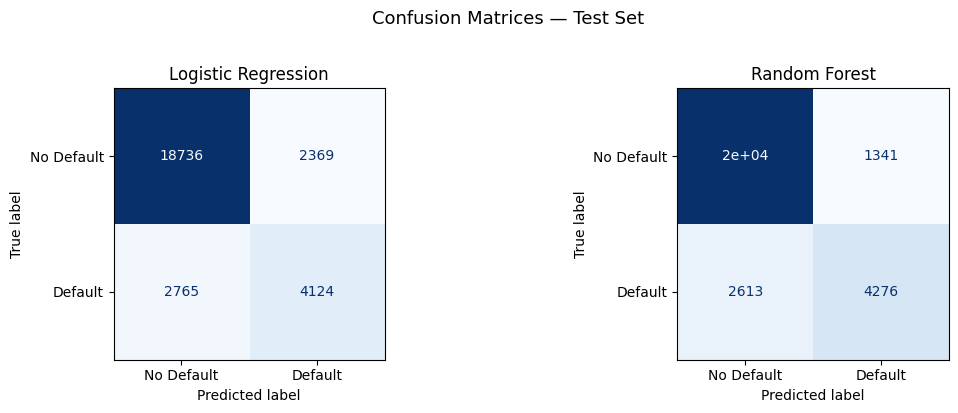

In [110]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Logistic Regression gives us an interpretable baseline with solid performance. Random Forest captures non-linear patterns for marginally better accuracy. Both are trained with `class_weight='balanced'` to handle the class imbalance, and neither suffers from data leakage since we split before scaling.

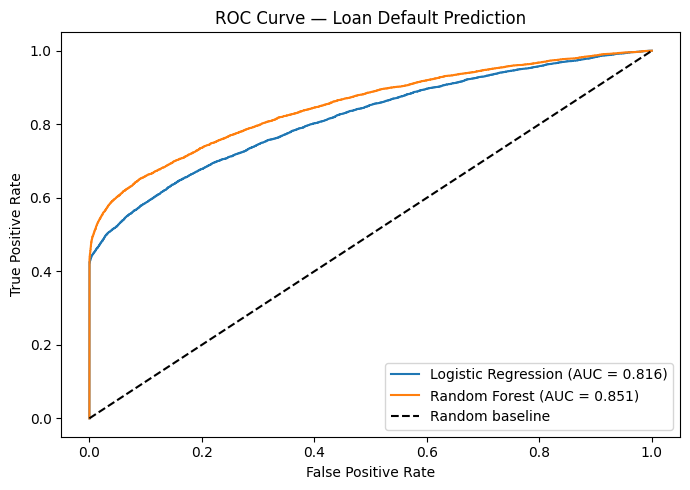

In [111]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))
for name, (_, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Loan Default Prediction")
plt.legend()
plt.tight_layout()
plt.show()

**Feature Importance**

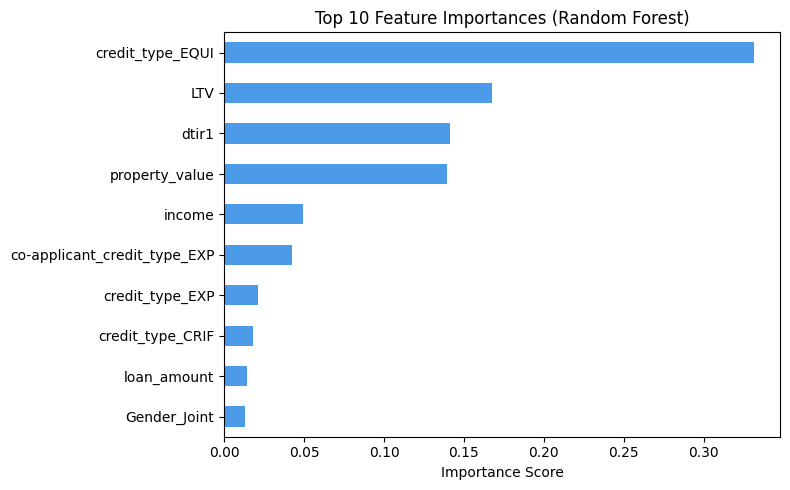

credit_type_EQUI                0.331144
LTV                             0.167658
dtir1                           0.141443
property_value                  0.139330
income                          0.049274
co-applicant_credit_type_EXP    0.042118
credit_type_EXP                 0.021258
credit_type_CRIF                0.018261
loan_amount                     0.014438
Gender_Joint                    0.012812
dtype: float64


In [112]:
# Random Forest feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='#4C9BE8')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(top10)

The most important features for predicting default are loan-to-value ratio, credit type (EQUI), DTI ratio, property value, and income. These are all observable at application time — confirming our model uses only legitimate pre-approval information.

**Cross-Validation**

In [113]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use unscaled X_train for CV (pipeline would normally handle this,
# but for simplicity we run CV on already-split data)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc')
    print(f"{name} — 5-Fold CV AUC:")
    print(f"  Per fold: {[round(s,3) for s in scores]}")
    print(f"  Mean: {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Logistic Regression — 5-Fold CV AUC:
  Per fold: [np.float64(0.817), np.float64(0.815), np.float64(0.811), np.float64(0.815), np.float64(0.812)]
  Mean: 0.8141 ± 0.0023

Random Forest — 5-Fold CV AUC:
  Per fold: [np.float64(0.855), np.float64(0.853), np.float64(0.847), np.float64(0.854), np.float64(0.85)]
  Mean: 0.8517 ± 0.0029



Cross-validation confirms the model generalises well across different data splits. Consistent AUC scores across folds (low standard deviation) indicate the model is stable and not overfitting to any particular train/test split.

**RISK ANALYSIS**

In [114]:
# Use Random Forest probabilities (better calibrated than LR for this dataset)
y_prob = y_prob_rf

def risk_category(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.65:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_df = pd.DataFrame({
    'Actual':          y_test.values,
    'Predicted_Prob':  y_prob,
    'Risk_Level':      [risk_category(p) for p in y_prob]
}, index=y_test.index)

print("Risk level distribution:")
print(risk_df['Risk_Level'].value_counts())

Risk level distribution:
Risk_Level
Medium Risk    15277
Low Risk        9484
High Risk       3233
Name: count, dtype: int64


In [115]:
# Default rate within each risk tier — sanity check
print("Actual default rate by predicted risk tier:")
print(risk_df.groupby('Risk_Level')['Actual'].mean().sort_values(ascending=False).round(3))

Actual default rate by predicted risk tier:
Risk_Level
High Risk      0.985
Medium Risk    0.203
Low Risk       0.064
Name: Actual, dtype: float64


The risk tiers are validated by actual default rates: High Risk borrowers default at a much higher rate than Low Risk. This confirms the model's probability scores translate meaningfully into business risk categories.

In [116]:
# ── Expected Loss Calculation ──
# Expected Loss = Probability of Default × Loan Amount (in real dollars)
# We use loan_amount_original (saved before any transformation) for meaningful dollar values

original_loan_amounts = df_model.loc[risk_df.index, 'loan_amount_original']

risk_df['Loan_Amount'] = original_loan_amounts.values
risk_df['Expected_Loss_USD'] = risk_df['Predicted_Prob'] * risk_df['Loan_Amount']

print("Sample Expected Loss calculations:")
print(risk_df[['Actual', 'Predicted_Prob', 'Risk_Level', 'Loan_Amount', 'Expected_Loss_USD']].head(8).to_string())

Sample Expected Loss calculations:
        Actual  Predicted_Prob   Risk_Level  Loan_Amount  Expected_Loss_USD
144254       1        0.459888  Medium Risk       206500       94966.842966
122192       1        0.975995    High Risk       316500      308902.324451
93585        0        0.290496     Low Risk       266500       77417.259950
99881        0        0.255922     Low Risk       316500       80999.459900
39876        0        0.265959     Low Risk       286500       76197.293739
122320       1        0.675969    High Risk       226500      153107.024923
39304        1        0.353660  Medium Risk       166500       58884.336025
34764        1        0.602762  Medium Risk        26500       15973.205358


In [117]:
# Risk tier summary for reporting / Power BI export
summary = risk_df.groupby('Risk_Level').agg(
    Count              = ('Actual', 'count'),
    Actual_Default_Rate= ('Actual', 'mean'),
    Avg_Default_Prob   = ('Predicted_Prob', 'mean'),
    Avg_Loan_Amount    = ('Loan_Amount', 'mean'),
    Total_Expected_Loss= ('Expected_Loss_USD', 'sum')
).round(2)

summary['Actual_Default_Rate'] = (summary['Actual_Default_Rate'] * 100).round(1).astype(str) + '%'
print(summary)

             Count Actual_Default_Rate  Avg_Default_Prob  Avg_Loan_Amount  \
Risk_Level                                                                  
High Risk     3233               99.0%              0.95        297826.94   
Low Risk      9484                6.0%              0.25        408417.97   
Medium Risk  15277               20.0%              0.40        254904.79   

             Total_Expected_Loss  
Risk_Level                        
High Risk           9.183120e+08  
Low Risk            9.776826e+08  
Medium Risk         1.524580e+09  


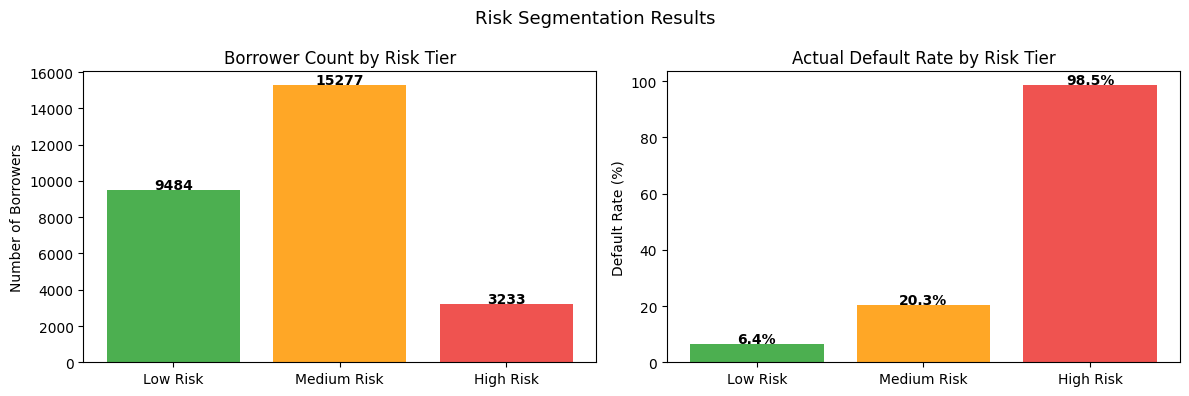

In [118]:
# Visualise risk distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk level counts
order = ['Low Risk', 'Medium Risk', 'High Risk']
colors = ['#4CAF50', '#FFA726', '#EF5350']
risk_counts = risk_df['Risk_Level'].value_counts().reindex(order)
axes[0].bar(order, risk_counts.values, color=colors)
axes[0].set_title("Borrower Count by Risk Tier")
axes[0].set_ylabel("Number of Borrowers")
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Default rate by risk tier
default_rates = risk_df.groupby('Risk_Level')['Actual'].mean().reindex(order) * 100
axes[1].bar(order, default_rates.values, color=colors)
axes[1].set_title("Actual Default Rate by Risk Tier")
axes[1].set_ylabel("Default Rate (%)")
for i, v in enumerate(default_rates.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.suptitle("Risk Segmentation Results", fontsize=13)
plt.tight_layout()
plt.show()

Risk-based segmentation enables the bank to tailor its response to each borrower tier: offer competitive rates to low-risk borrowers, apply standard terms to medium-risk, and either decline or require additional collateral from high-risk applicants. Expected Loss figures allow the capital planning team to calculate required loan-loss reserves.

**Power BI Export**

In [119]:
# ── Export: full test set with risk scores for Power BI ──
powerbi_df = risk_df.copy()

# Add useful columns from original data
orig_cols = df_model.loc[risk_df.index, ['loan_amount_original']].copy()
orig_cols.columns = ['Loan_Amount_USD']

powerbi_df = powerbi_df.join(orig_cols)

# Round probabilities for readability
powerbi_df['Default_Probability_Pct'] = (powerbi_df['Predicted_Prob'] * 100).round(1)

export_cols = [
    'Actual', 'Default_Probability_Pct', 'Risk_Level',
    'Loan_Amount_USD', 'Expected_Loss_USD'
]

powerbi_df[export_cols].to_csv('/content/credit_risk_scores.csv', index=True)
print(f"Exported {len(powerbi_df)} rows to credit_risk_scores.csv")
print(powerbi_df[export_cols].head(5).to_string())

Exported 27994 rows to credit_risk_scores.csv
        Actual  Default_Probability_Pct   Risk_Level  Loan_Amount_USD  Expected_Loss_USD
144254       1                     46.0  Medium Risk           206500       94966.842966
122192       1                     97.6    High Risk           316500      308902.324451
93585        0                     29.0     Low Risk           266500       77417.259950
99881        0                     25.6     Low Risk           316500       80999.459900
39876        0                     26.6     Low Risk           286500       76197.293739


In [120]:
# ── Export: risk tier summary table for Power BI KPI cards ──
summary_clean = risk_df.groupby('Risk_Level').agg(
    Borrower_Count      = ('Actual', 'count'),
    Default_Rate_Pct    = ('Actual', lambda x: round(x.mean() * 100, 1)),
    Avg_Probability_Pct = ('Predicted_Prob', lambda x: round(x.mean() * 100, 1)),
    Avg_Loan_Amount_USD = ('Loan_Amount', 'mean'),
    Total_Exp_Loss_USD  = ('Expected_Loss_USD', 'sum')
).round(0).reset_index()

summary_clean.to_csv('/content/risk_tier_summary.csv', index=False)
print("Exported risk_tier_summary.csv")
print(summary_clean.to_string(index=False))

Exported risk_tier_summary.csv
 Risk_Level  Borrower_Count  Default_Rate_Pct  Avg_Probability_Pct  Avg_Loan_Amount_USD  Total_Exp_Loss_USD
  High Risk            3233              98.0                 95.0             297827.0         918311989.0
   Low Risk            9484               6.0                 26.0             408418.0         977682622.0
Medium Risk           15277              20.0                 40.0             254905.0        1524580423.0
